<a href="https://colab.research.google.com/github/AdaTatulescu/experience_prediction_svm/blob/main/SVM_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# P2. Classification on the Salary Insights by Job Role

Task: load the Salary Insights by Job Role dataset, write a Support Vector Machine to perform classification over which is the experience_level of an employee.
![BMW](https://storage.googleapis.com/kaggle-datasets-images/8707166/13690104/e7a0bb06551f3e3b76d5d232876aa36d/dataset-cover.jpg?t=2025-11-11-07-16-12)


## Task 0: Import libraries ✅

All the libraries in this section should be enough for the project. If you want to, you can import more libraries.

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

## Task 1: Download/Import Dataset 📃

Link: https://www.kaggle.com/datasets/zahranusrat/salary

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
# Make sure to upload the data in colab
# Importing our dataset
df = pd.read_csv("/content/drive/MyDrive/???")
df.head(5)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


## Task 2: Exploring the data 📃

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           16534 non-null  int64 
 1   experience_level    16534 non-null  object
 2   employment_type     16534 non-null  object
 3   job_title           16534 non-null  object
 4   salary              16534 non-null  int64 
 5   salary_currency     16534 non-null  object
 6   salary_in_usd       16534 non-null  int64 
 7   employee_residence  16534 non-null  object
 8   remote_ratio        16534 non-null  int64 
 9   company_location    16534 non-null  object
 10  company_size        16534 non-null  object
dtypes: int64(4), object(7)
memory usage: 1.4+ MB


In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [ ]:
# unique entries in experience_level

print(df['experience_level'].unique())

['SE' 'MI' 'EN' 'EX']


In [ ]:
for i in df.columns:
  print(i)
  print(df[i].unique())

work_year
[2024 2022 2023 2020 2021]
experience_level
['SE' 'MI' 'EN' 'EX']
employment_type
['FT' 'CT' 'PT' 'FL']
job_title
['AI Engineer' 'Data Engineer' 'Machine Learning Engineer' 'ML Engineer'
 'Data Analyst' 'NLP Engineer' 'Data Scientist' 'Applied Scientist'
 'Data Manager' 'Data Architect' 'Data Operations Manager'
 'Research Scientist' 'Data Science Manager'
 'Business Intelligence Engineer' 'Business Intelligence' 'Data Modeler'
 'Data Integration Specialist' 'Data Product Manager'
 'Data Visualization Specialist' 'Data Science' 'Data Specialist'
 'Business Intelligence Lead' 'Research Analyst'
 'Business Intelligence Analyst' 'AI Software Engineer'
 'Machine Learning Scientist' 'Data Science Engineer'
 'Machine Learning Operations Engineer' 'Analytics Engineer'
 'Data Management Analyst' 'Encounter Data Management Professional'
 'Data Analytics Specialist' 'Head of Data' 'Data Analytics Lead'
 'Research Engineer' 'AI Scientist' 'Business Intelligence Developer'
 'Machine Lear

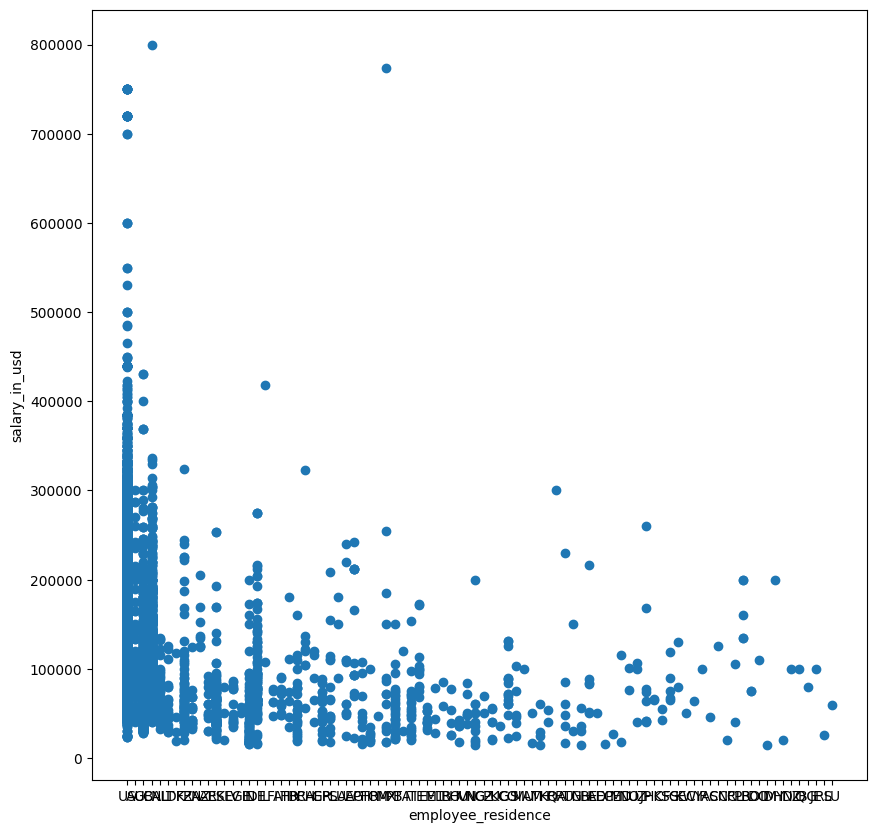

In [ ]:
#plot graph of correlation between employee_residence and salary_in_usd
plt.figure(figsize=(10,10))
plt.scatter(df['employee_residence'], df['salary_in_usd'])
plt.xlabel('employee_residence')
plt.ylabel('salary_in_usd')
plt.show()

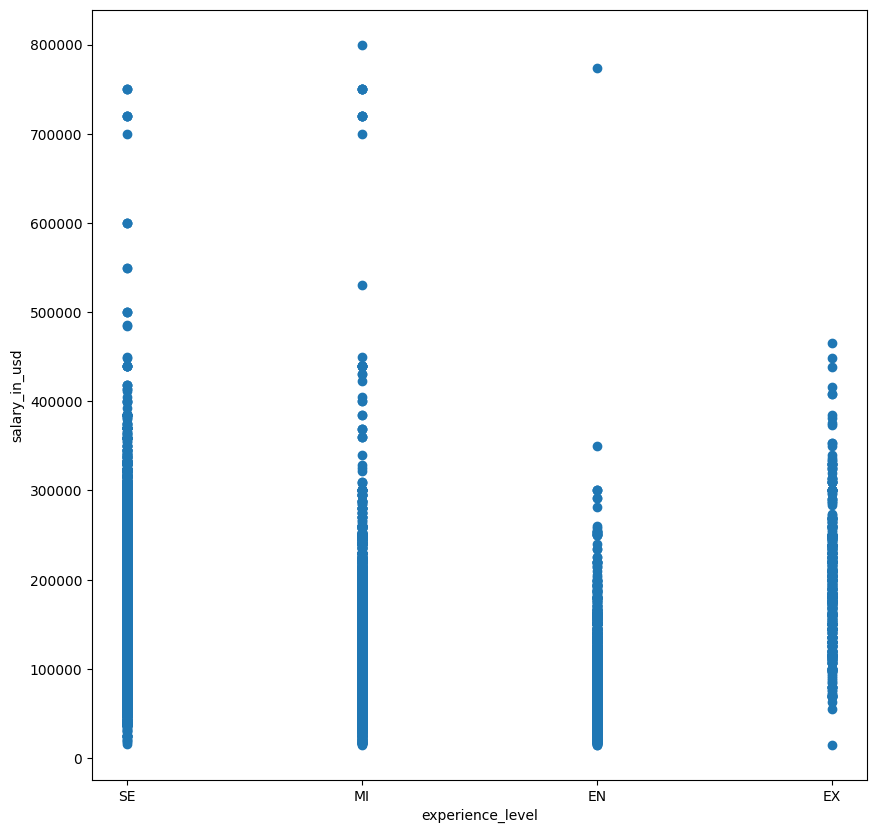

In [ ]:
#plot graph of correlation between experience_level and salary_in_usd

plt.figure(figsize=(10,10))
plt.scatter(df['experience_level'], df['salary_in_usd'])
plt.xlabel('experience_level')
plt.ylabel('salary_in_usd')
plt.show()

# Median Salary in USD VS Experiencd Level

Plotting the correlation between median salary in USD and experience level is important, as it allows us to assess whether employee seniority is influenced by income.

In [ ]:
df["salary_in_usd"].value_counts()
row_min = df.loc[df['salary_in_usd'].idxmin()]
row_max = df.loc[df['salary_in_usd'].idxmax()]

print("Cel mai mic salariu:", row_min['salary_in_usd'], "| Job Title:", row_min['job_title'])
print("Cel mai mare salariu:", row_max['salary_in_usd'], "| Job Title:", row_max['job_title'])


Cel mai mic salariu: 15000 | Job Title: Business Intelligence Developer
Cel mai mare salariu: 800000 | Job Title: AI Architect


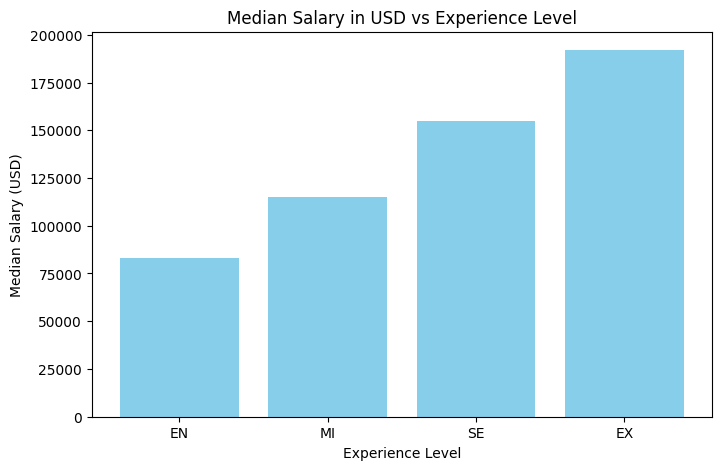

In [ ]:
experience_order = ["EN", "MI", "SE", "EX"]
median_by_experience = (
    df.groupby("experience_level")["salary_in_usd"]
      .median()
      .reindex(experience_order)
)

plt.figure(figsize=(8, 5))
plt.bar(median_by_experience.index, median_by_experience.values, color="skyblue")
plt.xlabel("Experience Level")
plt.ylabel("Median Salary (USD)")
plt.title("Median Salary in USD vs Experience Level")
plt.show()


NOTE:                                                                         
We can observe that experience level influences salary, which means that salary in USD can be used as an indirect indicator of an employee's experience. In the following plots, salary will be used to depict whether other variables provide meaningful or relevant information. As a continuous variable, salary_in_usd offers additional insight into the dataset and helps reveal dependencies between features.


### Number of people in each class

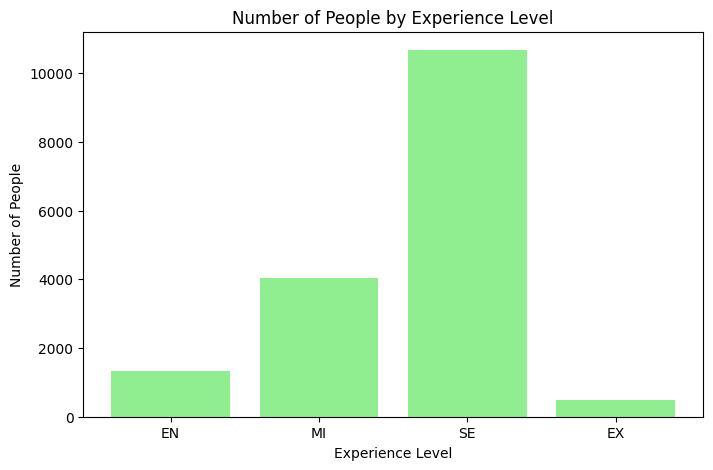

In [ ]:
experience_order = ["EN", "MI", "SE", "EX"]
count_by_experience = df["experience_level"].value_counts().reindex(experience_order)
plt.figure(figsize=(8, 5))
plt.bar(count_by_experience.index, count_by_experience.values, color="lightgreen")
plt.xlabel("Experience Level")
plt.ylabel("Number of People")
plt.title("Number of People by Experience Level")
plt.show()


# Median Salary VS Work Years

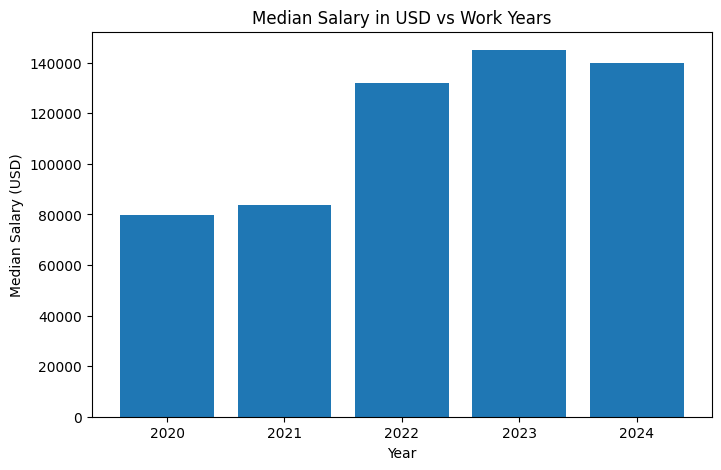

In [ ]:
median_by_year = df.groupby("work_year")["salary_in_usd"].median()

plt.figure(figsize=(8,5))
plt.bar(median_by_year.index, median_by_year.values)
plt.xlabel("Year")
plt.ylabel("Median Salary (USD)")
plt.title("Median Salary in USD vs Work Years")
plt.show()


In [ ]:
df["work_year"].value_counts()

,count
work_year,
2023,8519
2024,6067
2022,1655
2021,218
2020,75


NOTE:                                                                         
The salary is influenced by the work year, as shown in the plot, so we will treat work_year as a continuous variable. It is relevant for the classification task due to its indirect influence on the experience_level.

## Employee Residence

In [ ]:
df["employee_residence"].value_counts()

,count
employee_residence,
US,14467
GB,686
CA,453
ES,137
DE,98
...,...
IQ,1
BG,1
JE,1


NOTE:                                                                           
We can observe that many countries have very few representatives, which may introduce noise and negatively impact the model's performance. To improve classification accuracy, countries with fewer than 50 representatives will be grouped into a separate category 'Other'. This ensures that the model can generalize more effectively, as it would otherwise struggle to classify future instances from underrepresented countries.

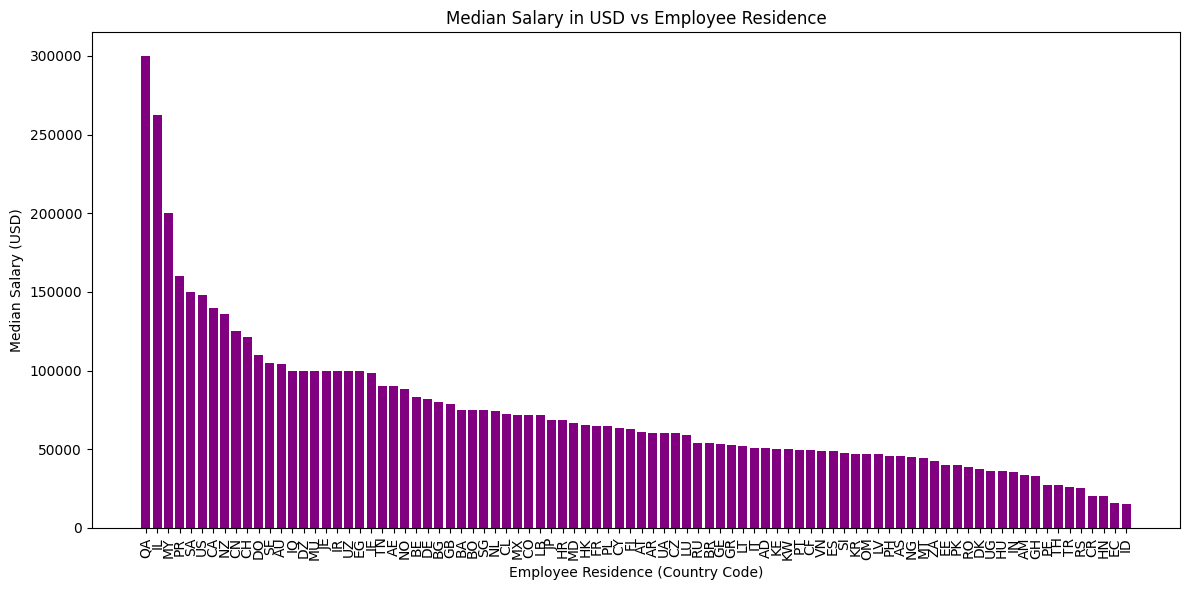

In [ ]:
import matplotlib.pyplot as plt

median_by_residence = (
    df.groupby("employee_residence")["salary_in_usd"]
      .median()
      .sort_values(ascending=False))

plt.figure(figsize=(12, 6))
plt.bar(median_by_residence.index, median_by_residence.values, color="purple")

plt.xlabel("Employee Residence (Country Code)")
plt.ylabel("Median Salary (USD)")
plt.title("Median Salary in USD vs Employee Residence")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


## Employment Type => not needed

In [ ]:
df["employment_type"].value_counts()
#FT >> PT,CT,FL => employment_type not relevant
#Dataset does not provide enough representants from PT, CT and FL in order to take these classes into consideration, it would only introduce unwanted noise

,count
employment_type,
FT,16454
PT,38
CT,28
FL,14


## Company Size

In [ ]:
df["company_size"].value_counts()

,count
company_size,
M,15306
L,1040
S,188


NOTE:                                                                           
Medium-sized companies account for a large portion of the employees, but the proportions of small and large companies should not be overlooked.

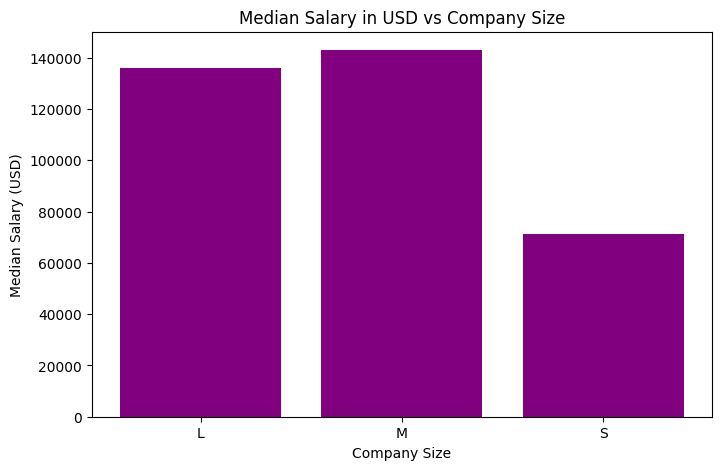

In [ ]:
median_by_company = df.groupby("company_size")["salary_in_usd"].median().sort_index()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(median_by_company.index, median_by_company.values, color="purple")

plt.xlabel("Company Size")
plt.ylabel("Median Salary (USD)")
plt.title("Median Salary in USD vs Company Size")
plt.show()

Note:                                                                     
Medium companies can have higher median salaries than large ones due to more specialized roles, fewer entry-level employees, and cash-focused pay, while large companies have many low-salary positions and benefits outside salary_in_usd.

## Job Title

In [ ]:
unique_junior_titles = df[df["experience_level"] == "EN"]["job_title"].unique()

print("Unique job titles for juniors:")
for title in unique_junior_titles:
    print(title)


Unique job titles for juniors:
Data Analyst
Data Engineer
AI Software Engineer
Data Scientist
Business Intelligence Analyst
Research Scientist
Data Science
Business Intelligence Developer
Business Intelligence Lead
ML Engineer
Research Analyst
Business Intelligence
Data Management Analyst
Research Engineer
Business Intelligence Engineer
Machine Learning Engineer
Machine Learning Operations Engineer
Data Specialist
Applied Scientist
Data Operations Analyst
Data Science Analyst
Applied Data Scientist
Insight Analyst
Analytics Engineer
BI Analyst
Data Reporting Analyst
Data DevOps Engineer
AI Research Scientist
Quantitative Research Analyst
Machine Learning Research Engineer
Big Data Engineer
Data Operations Associate
AI Engineer
Data Analytics Manager
Data Integration Engineer
Admin & Data Analyst
Data Analytics Specialist
Data Quality Analyst
Data Developer
Data Manager
Data Visualization Specialist
Data Analyst Lead
MLOps Engineer
BI Data Analyst
Data Integration Specialist
AI Research

In [ ]:
unique_junior_titles = df[df["experience_level"] == "SE"]["job_title"].unique()

print("Unique job titles for SE:")
for title in unique_junior_titles:
    print(title)


Unique job titles for SE:
AI Engineer
Data Engineer
Machine Learning Engineer
Data Analyst
Applied Scientist
Data Architect
Business Intelligence Engineer
Data Scientist
Data Modeler
Data Manager
Research Scientist
Data Science
Business Intelligence Lead
Research Analyst
ML Engineer
Machine Learning Scientist
Business Intelligence
Data Management Analyst
Encounter Data Management Professional
Data Analytics Lead
Data Specialist
Analytics Engineer
AI Scientist
Business Intelligence Analyst
Research Engineer
AI Software Engineer
Data Infrastructure Engineer
Insight Analyst
Consultant Data Engineer
Manager Data Management
Data Science Engineer
Robotics Engineer
Business Intelligence Specialist
Data Operations Analyst
Data Science Manager
Data Product Owner
Data Science Consultant
Business Intelligence Developer
Data Lead
AI Architect
Lead Data Scientist
MLOps Engineer
Data Quality Manager
BI Analyst
Applied Research Scientist
Prompt Engineer
Data Integration Engineer
Machine Learning Infr

In [ ]:
unique_junior_titles = df[df["experience_level"] == "EX"]["job_title"].unique()

print("Unique job titles for EX:")
for title in unique_junior_titles:
    print(title)


Unique job titles for EX:
NLP Engineer
Data Science
Research Analyst
Head of Data
Business Intelligence
Data Engineer
Director of Business Intelligence
Data Analyst
ML Engineer
Machine Learning Engineer
AI Engineer
Business Intelligence Analyst
Data Architect
Data Science Director
Data Science Engineer
Data Scientist
ETL Engineer
Head of Machine Learning
BI Developer
Business Intelligence Engineer
Director of Data Science
Managing Director Data Science
Business Intelligence Developer
Analytics Engineer
Data Lead
Research Scientist
Data Science Manager
Data Manager
Head of Data Science
AI Architect
Applied Machine Learning Engineer
Staff Data Analyst
Data Analytics Manager
Machine Learning Scientist
AI Scientist
Lead Data Engineer
BI Data Analyst
Data Science Consultant
Principal Data Scientist


In [ ]:
unique_junior_titles = df[df["experience_level"] == "MI"]["job_title"].unique()

print("Unique job titles for ME:")
for title in unique_junior_titles:
    print(title)


Unique job titles for ME:
ML Engineer
Data Scientist
Data Manager
Data Operations Manager
Research Scientist
Data Analyst
Data Science Manager
Business Intelligence
Data Integration Specialist
Data Engineer
Data Product Manager
Data Visualization Specialist
Data Specialist
Business Intelligence Analyst
AI Engineer
Data Science Engineer
Machine Learning Operations Engineer
Machine Learning Engineer
Applied Scientist
Research Analyst
Analytics Engineer
Data Analytics Specialist
Machine Learning Scientist
Data Science
Research Engineer
Machine Learning Developer
Data Management Specialist
Business Intelligence Engineer
Encounter Data Management Professional
Data Infrastructure Engineer
BI Developer
Admin & Data Analyst
Business Intelligence Manager
Data Quality Manager
Data Analytics Manager
Business Intelligence Developer
AI Research Scientist
Data Operations Specialist
Bear Robotics
Data Operations Associate
Data Product Owner
Data Modeler
Data Developer
Data Integration Engineer
ETL De

In [ ]:
df["job_title"].value_counts()

,count
job_title,
Data Engineer,3464
Data Scientist,3314
Data Analyst,2440
Machine Learning Engineer,1705
Research Scientist,531
...,...
BI Data Engineer,1
Marketing Data Engineer,1
Data Science Tech Lead,1




Note:                                                                         
Job titles cannot be reliably grouped by keywords because the dataset is highly inconsistent and titles vary too much in structure. Keyword grouping would mix unrelated roles, producing inaccurate clusters and weakening the model's predictive performance. However, I have tried to group them in order to better see the results.


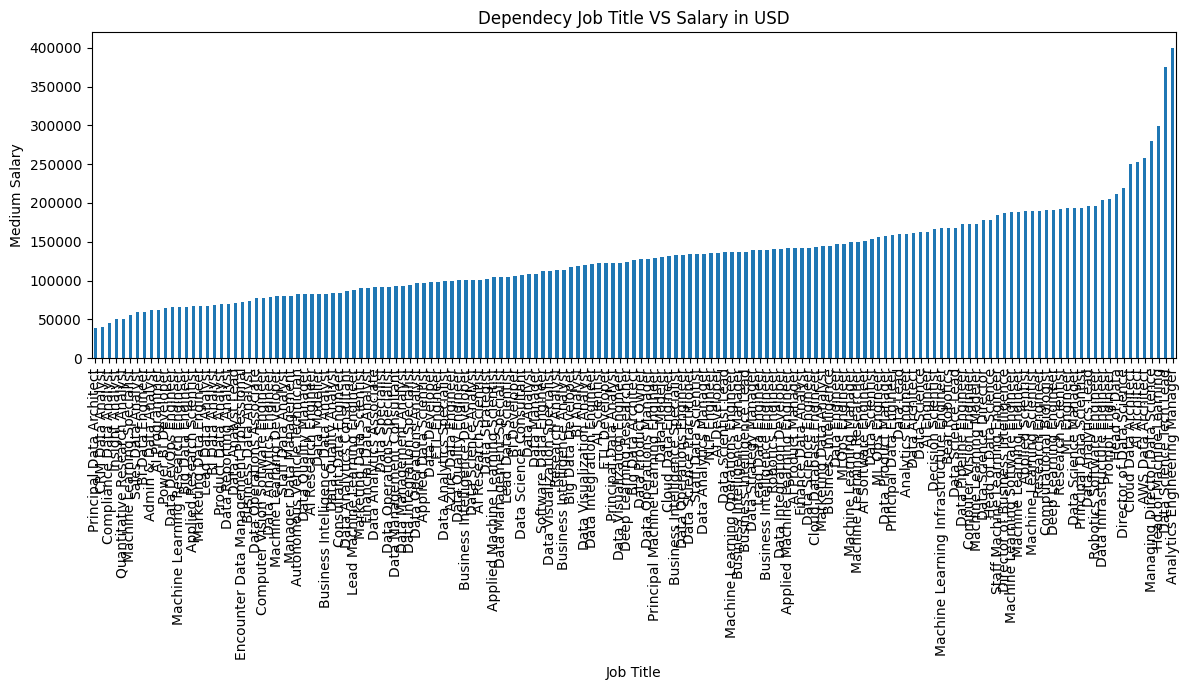

In [ ]:
salary_by_job = df.groupby('job_title')['salary_in_usd'].mean().sort_values()

plt.figure(figsize=(12, 7))
salary_by_job.plot(kind='bar')
plt.title('Dependecy Job Title VS Salary in USD')
plt.xlabel('Job Title')
plt.ylabel('Medium Salary')
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()


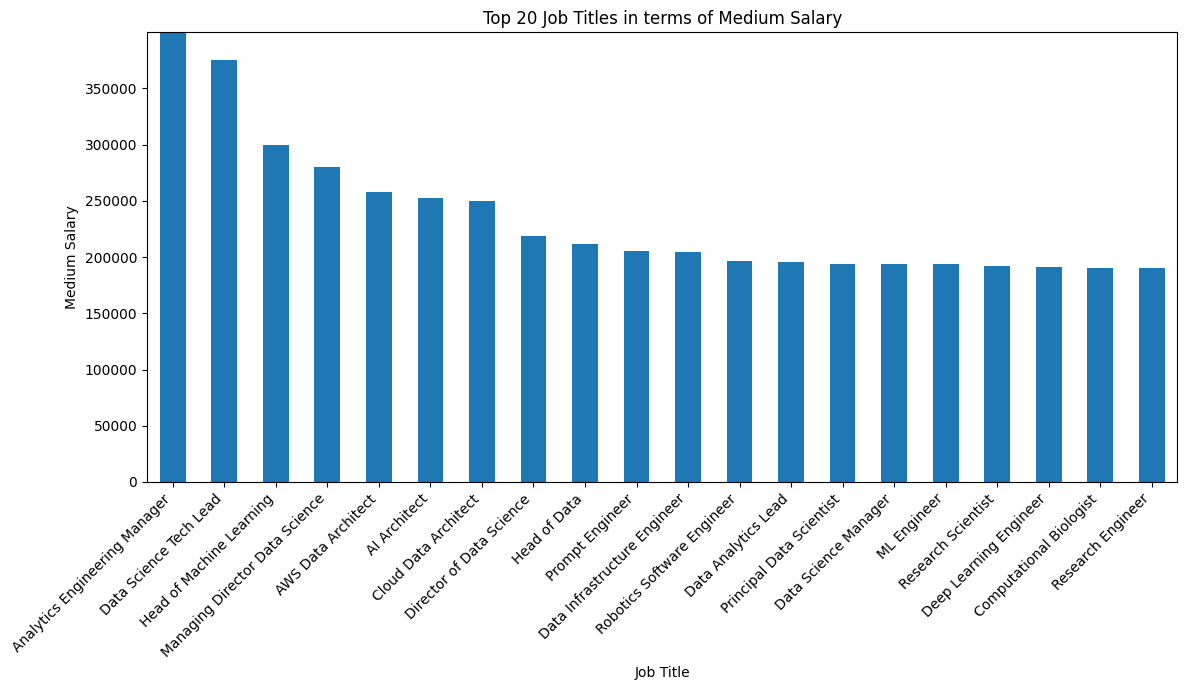

In [ ]:

salary_by_job = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)

top20 = salary_by_job.head(20) # top 20 job titles

plt.figure(figsize=(12, 7))
top20.plot(kind='bar')

plt.ylim(0, top20.max())

plt.title('Top 20 Job Titles in terms of Medium Salary')
plt.xlabel('Job Title')
plt.ylabel('Medium Salary')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


NOTE:                                                                           
This plot highlights the variation in salaries across roles. Although some titles share keywords such as 'Manager', 'Lead', or 'Architect', these overlap with 'Data' titles, which may introduce ambiguity and lead to confusion for the model.

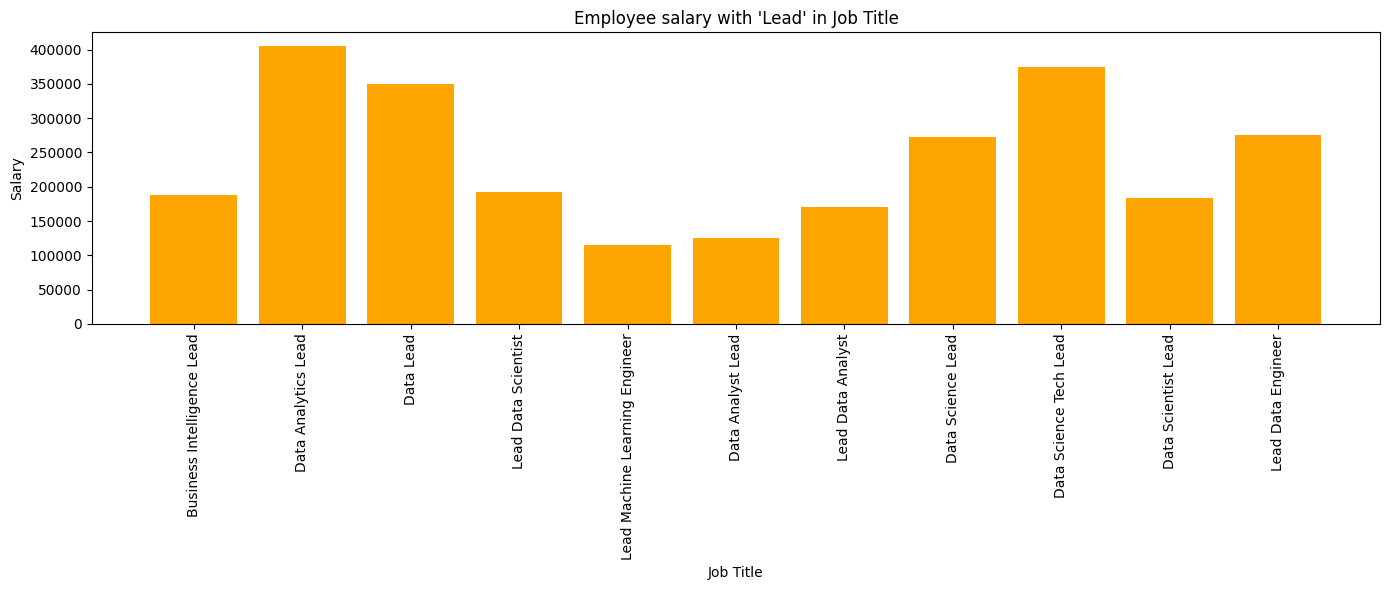

In [ ]:
lead_df = df[df["job_title"].str.contains("Lead", case=False, na=False)]

plt.figure(figsize=(14, 6))
plt.bar(lead_df["job_title"], lead_df["salary_in_usd"], color="orange")
plt.xticks(rotation=90)
plt.xlabel("Job Title")
plt.ylabel("Salary")
plt.title("Employee salary with 'Lead' in Job Title")
plt.tight_layout()

plt.show()


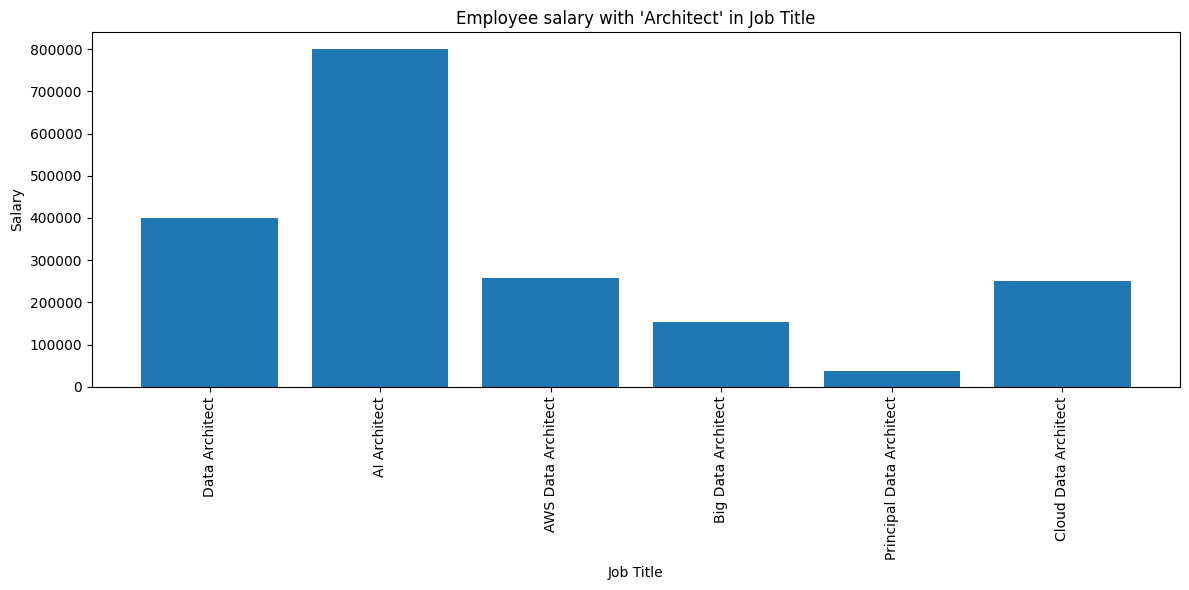

In [ ]:
arch_df = df[df["job_title"].str.contains("architect", case=False, na=False)]

plt.figure(figsize=(12, 6))
plt.bar(arch_df["job_title"], arch_df["salary_in_usd"])
plt.xticks(rotation=90)
plt.xlabel("Job Title")
plt.ylabel("Salary")
plt.title("Employee salary with 'Architect' in Job Title")
plt.tight_layout()
plt.show()

NOTE:                                                                           
The plots I have created show significant salary variation among job titles containing terms 'Lead' or 'Architect', indicating that these roles are not homogeneous despite sharing common keywords.

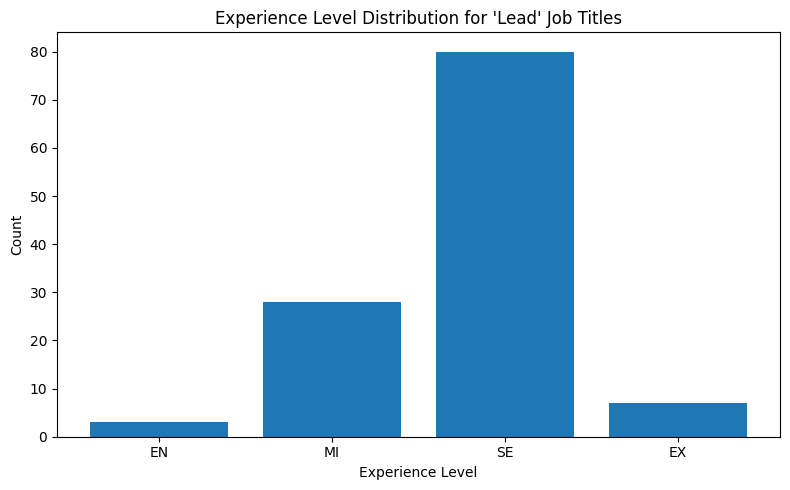

In [ ]:
# 'Lead' in job_title

lead_df = df[df["job_title"].str.contains("Lead", case=False, na=False)]
exp_counts = lead_df["experience_level"].value_counts().reindex(["EN", "MI", "SE", "EX"])

plt.figure(figsize=(8,5))
plt.bar(exp_counts.index, exp_counts.values)
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.title("Experience Level Distribution for 'Lead' Job Titles")
plt.tight_layout()
plt.show()

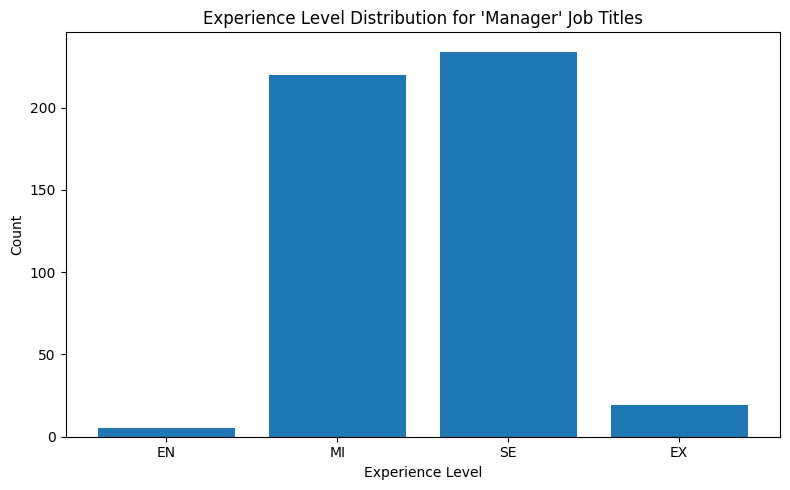

In [ ]:
# 'Manager' in job_title

lead_df = df[df["job_title"].str.contains("Manager", case=False, na=False)]
exp_counts = lead_df["experience_level"].value_counts().reindex(["EN", "MI", "SE", "EX"])

plt.figure(figsize=(8,5))
plt.bar(exp_counts.index, exp_counts.values)
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.title("Experience Level Distribution for 'Manager' Job Titles")
plt.tight_layout()
plt.show()

NOTE:                                                                           
Even though keywords such as 'Lead' and 'Manager' are generally associated with senior or higher-level roles, the results are not fully reliable due to inconsistent data distribution and an insufficient number of representatives in classes like EN and EX

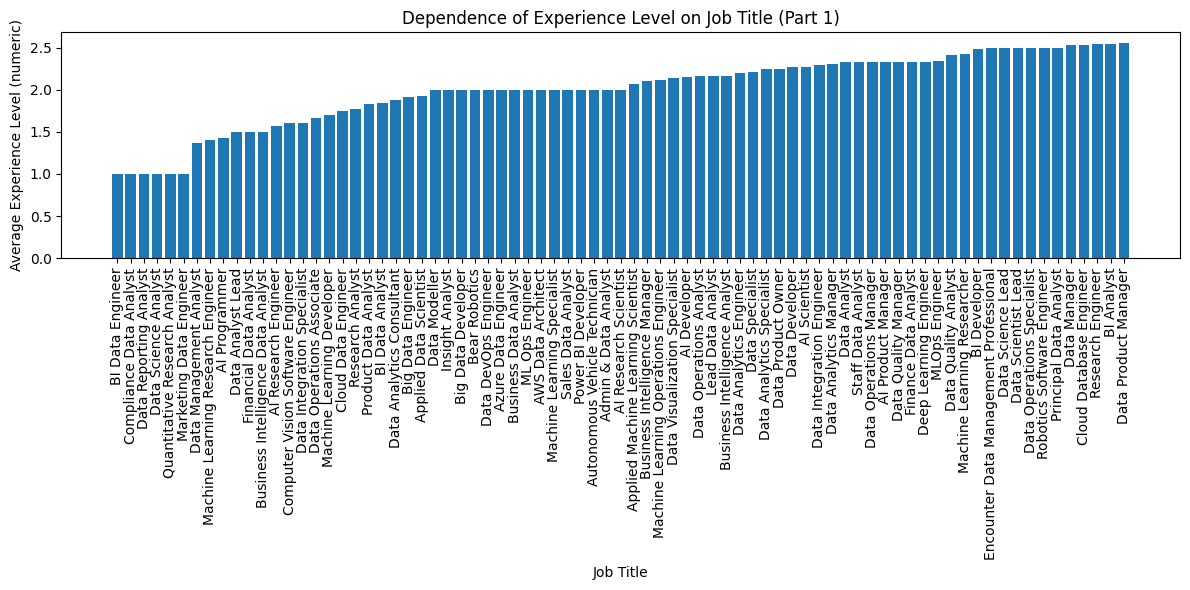

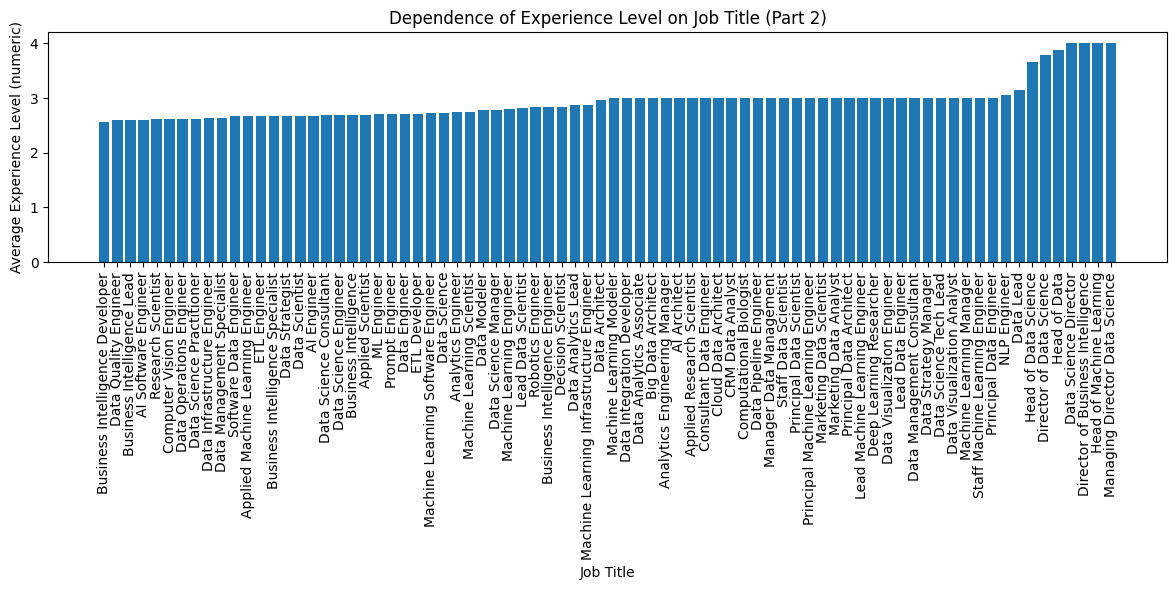

In [ ]:
exp_map = {"EN": 1, "MI": 2, "SE": 3, "EX": 4}
df["exp_num"] = df["experience_level"].map(exp_map)

exp_by_job = df.groupby("job_title")["exp_num"].mean().sort_values()

mid = len(exp_by_job) // 2
first_half = exp_by_job.iloc[:mid]
second_half = exp_by_job.iloc[mid:]

# plot 1
plt.figure(figsize=(12, 6))
plt.bar(first_half.index, first_half.values)
plt.xticks(rotation=90)
plt.xlabel("Job Title")
plt.ylabel("Average Experience Level (numeric)")
plt.title("Dependence of Experience Level on Job Title (Part 1)")
plt.tight_layout()
plt.show()

# plot 2
plt.figure(figsize=(12, 6))
plt.bar(second_half.index, second_half.values)
plt.xticks(rotation=90)
plt.xlabel("Job Title")
plt.ylabel("Average Experience Level (numeric)")
plt.title("Dependence of Experience Level on Job Title (Part 2)")
plt.tight_layout()
plt.show()


In [ ]:
df.drop('exp_num',axis=1,inplace=True)
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


## Task 3: Preparing the Data 📃
Normalization of the data

ONE-HOT ENCODING: job_title, residence_grouped, remote_ratio, company_size     
Note: we need to transform them into numerical representation, as they are relevant atributes for our model and offer important classifying information.

CONTIUOUS DATA: salary_in_usd, work_year                                        
Note 1: I decided to consider salary_in_usd a continuous attribute, because it represents a numerical value rather than a categorical label. It provides information on how salary can influence seniority.                   
Note 2: I decided to consider work_year a continuous attribute, because its chronological order provides information on how salary is influenced by financial and market trends.

NOT NEEDED: employment_type, salary, salary_currency, employee_residence, company_location, job_group                                           
Note: employment_type => unequally distributed representatives, salary => redundancy, salary_currency => not relevant, employee_residence => use residence_grouped instead, company_location => redundancy employee_residence, job_group => attribute created only for demonstration

### Grouping Employee Distribution By Country

In [ ]:
df["employee_residence"].value_counts()


,count
employee_residence,
US,14467
GB,686
CA,453
ES,137
DE,98
...,...
IQ,1
BG,1
JE,1


NOTE:                                                                   
Grouping employees by country helps reduce noise caused by underrepresented categories and makes the model more stable. Countries with very few employees do not provide enough data for the model to learn patterns, which can reduce accuracy. By combining these into a single “Other” category, we improve generalization and avoid misleading classifications.

In [ ]:
threshold = 250
country_counts = df["employee_residence"].value_counts()
rare_countries = country_counts[country_counts < threshold].index
df["residence_grouped"] = df["employee_residence"].replace(rare_countries, "Other")

In [ ]:
print(df["residence_grouped"].value_counts())


residence_grouped
US       14467
Other      928
GB         686
CA         453
Name: count, dtype: int64


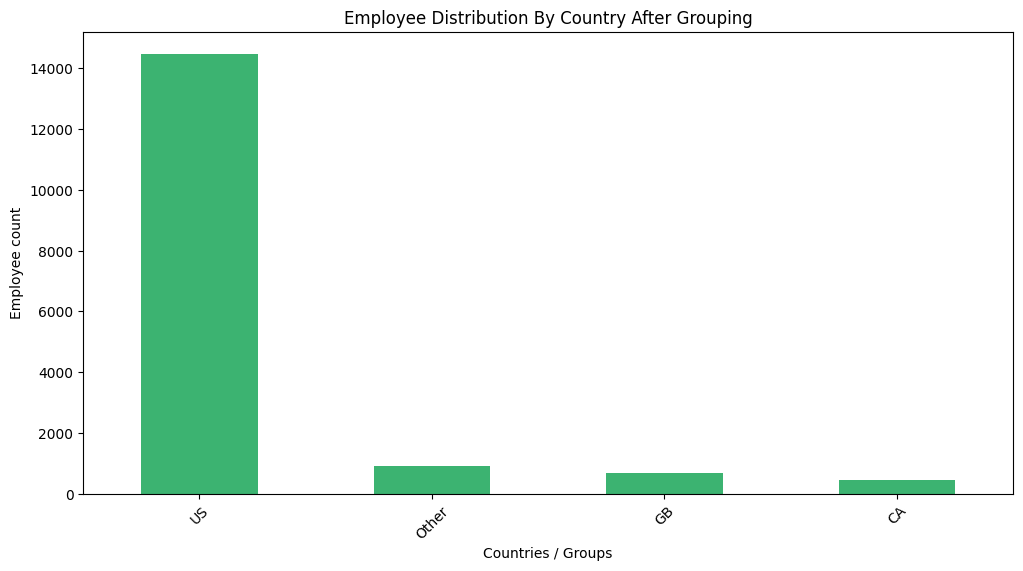

In [ ]:

counts = df["residence_grouped"].value_counts()

plt.figure(figsize=(12,6))
counts.plot(kind="bar", color="mediumseagreen")
plt.xlabel("Countries / Groups")
plt.ylabel("Employee count")
plt.title("Employee Distribution By Country After Grouping")
plt.xticks(rotation=45)
plt.show()


In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size',
       'residence_grouped'],
      dtype='object')

## Grouping Job Titles

In [ ]:
def map_job_title(title):
    t = title.lower()

    # Data Engineering
    if any(k in t for k in [
        "data engineer","bi data engineer","cloud data engineer","software data engineer",
        "big data","architect","aws data architect","cloud data architect",
        "data modeller","data modeler"
    ]):
        return "Data Engineering"

    # Data Science
    if any(k in t for k in [
        "data scientist","applied scientist","research scientist","ml scientist",
        "machine learning scientist","deep learning","data science engineer",
        "data science","tech lead","scientist lead"
    ]):
        return "Data Science"

    # ML/AI Engineering
    if any(k in t for k in [
        "machine learning engineer","ml engineer","ai engineer","ai software",
        "ai scientist","nlp","computer vision","applied machine learning",
        "machine learning operations","staff machine learning","ml specialist"
    ]):
        return "ML/AI Engineering"

    # Business Intelligence / Analytics Engineering
    if any(k in t for k in [
        "business intelligence","bi ","analytics engineer","analytics engineering manager",
        "data analytics","visualization","research analyst","management analyst"
    ]):
        return "BI / Analytics Engineering"

    # Data Analysis
    if "analyst" in t:
        return "Data Analysis"

    # Data Management / Operations
    if any(k in t for k in [
        "data manager","operations manager","data specialist","integration specialist",
        "data operations","data management"
    ]):
        return "Data Management / Operations"

    # Leadership
    if any(k in t for k in [
        "manager","head of","lead","principal","director"
    ]):
        return "Leadership"

    # Software / Other Engineering
    if any(k in t for k in [
        "software engineer","technician","computer vision software"
    ]):
        return "Software / Other Engineering"

    return "Other"

df["job_group"] = df["job_title"].apply(map_job_title)



In [ ]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size', 'residence_grouped',
       'job_group'],
      dtype='object')

## Columns to delete

In [ ]:

columns_to_delete = ['employment_type', 'salary', 'salary_currency','employee_residence','company_location','job_group']
df = df.drop(columns_to_delete, axis=1)
df.head()

,work_year,experience_level,job_title,salary_in_usd,remote_ratio,company_size,residence_grouped
0,2024,SE,AI Engineer,202730,0,M,US
1,2024,SE,AI Engineer,92118,0,M,US
2,2024,SE,Data Engineer,130500,0,M,US
3,2024,SE,Data Engineer,96000,0,M,US
4,2024,SE,Machine Learning Engineer,190000,0,M,US


## One-hot encoding

In [ ]:
df.columns

Index(['work_year', 'experience_level', 'job_title', 'salary_in_usd',
       'remote_ratio', 'company_size', 'residence_grouped'],
      dtype='object')

In [ ]:
onehot_fields = [
    'job_title',
    'residence_grouped',
    'remote_ratio',
    'company_size'
]

for field in onehot_fields:
    dummies = pd.get_dummies(df[field], prefix=field, drop_first=False)
    df = pd.concat([df, dummies], axis=1)

df = df.drop(onehot_fields, axis=1)

df.head()


,work_year,experience_level,salary_in_usd,job_title_AI Architect,job_title_AI Developer,job_title_AI Engineer,job_title_AI Product Manager,job_title_AI Programmer,job_title_AI Research Engineer,job_title_AI Research Scientist,...,residence_grouped_CA,residence_grouped_GB,residence_grouped_Other,residence_grouped_US,remote_ratio_0,remote_ratio_50,remote_ratio_100,company_size_L,company_size_M,company_size_S
0,2024,SE,202730,False,False,True,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
1,2024,SE,92118,False,False,True,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
2,2024,SE,130500,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
3,2024,SE,96000,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
4,2024,SE,190000,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False


## Continuous attributes

In [ ]:
continuous_fields = ['salary_in_usd','work_year']

scaled_features = {}
for field in continuous_fields:
    mean = df[field].mean()
    std = df[field].std()
    scaled_features[field] = [mean, std]
    df.loc[:, field] = (df[field] - mean)/std

df.head()

/tmp/ipython-input-3180922077.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.77429377 -0.84035518 -0.28007731 ... -0.65231132 -0.72529838
 -0.80317557]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, field] = (df[field] - mean)/std
/tmp/ipython-input-3180922077.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.08349161  1.08349161  1.08349161 ... -4.52221918 -4.52221918
 -3.12079148]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, field] = (df[field] - mean)/std


,work_year,experience_level,salary_in_usd,job_title_AI Architect,job_title_AI Developer,job_title_AI Engineer,job_title_AI Product Manager,job_title_AI Programmer,job_title_AI Research Engineer,job_title_AI Research Scientist,...,residence_grouped_CA,residence_grouped_GB,residence_grouped_Other,residence_grouped_US,remote_ratio_0,remote_ratio_50,remote_ratio_100,company_size_L,company_size_M,company_size_S
0,1.083492,SE,0.774294,False,False,True,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
1,1.083492,SE,-0.840355,False,False,True,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
2,1.083492,SE,-0.280077,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
3,1.083492,SE,-0.783688,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
4,1.083492,SE,0.588469,False,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False


## Task 3: Define the SVM 📃

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

param_grid = {
    "C": [0.5, 1, 5],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    n_jobs=-1
)

# Note 1:
 This is the result obtained when I did not include grouped job titles ("job_group") and only used them as they are in the dataset, because they cause too much noise and it is difficult to group them, as they are very diverse.
Best params: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
Validation accuracy: 0.7091555152339911

Test accuracy: 0.7121257937707892

Report:

                   precision    recall  f1-score   support

          EN       0.55      0.38      0.45       265
          EX       0.89      0.31      0.46       100
          MI       0.60      0.29      0.39       808
          SE       0.74      0.93      0.82      2134

    accuracy                           0.71      3307
    macro avg       0.69      0.48      0.53      3307
    weighted avg       0.69      0.71      0.68      3307


# NOTE 2:                                                                      
 This is the result obtained after excluding grouped job titles from the training and testing part, so we can conclude that it is important to take into consideration the job title.

Best params: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
Validation accuracy: 0.6762682392076812

Test accuracy: 0.6776534623525854

Report:
               precision    recall  f1-score   support

          EN       0.29      0.06      0.09       265
          EX       0.00      0.00      0.00       100
          MI       0.51      0.23      0.31       808
          SE       0.71      0.96      0.81      2134

    accuracy                           0.68      3307
   macro avg       0.38      0.31      0.30      3307
weighted avg       0.60      0.68      0.61      3307


## Task 4: Train 📃

In [ ]:
# Train/test split
X = df.drop("experience_level", axis=1)
y = df["experience_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Validation accuracy:", grid.best_score_)

best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)

Best params: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
Validation accuracy: 0.7091555152339911


## Task 6: Show results and compare different values of C 📃

In [ ]:
print("Best Params:", grid.best_params_)
print("Validation Accuracy:", grid.best_score_)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Params: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}
Validation Accuracy: 0.7091555152339911

Test Accuracy: 0.7121257937707892

Classification Report:
               precision    recall  f1-score   support

          EN       0.55      0.38      0.45       265
          EX       0.89      0.31      0.46       100
          MI       0.60      0.29      0.39       808
          SE       0.74      0.93      0.82      2134

    accuracy                           0.71      3307
   macro avg       0.69      0.48      0.53      3307
weighted avg       0.69      0.71      0.68      3307



## Confusion Matrix

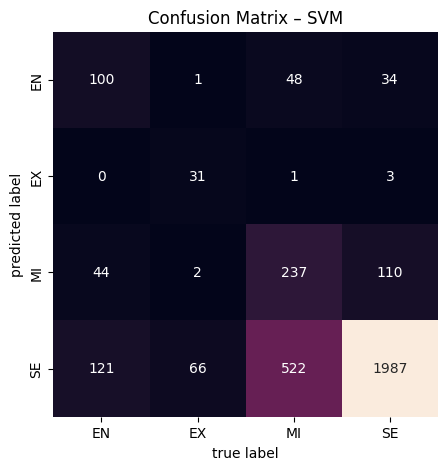

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    mat.T,
    square=True,
    annot=True,
    fmt="d",
    cbar=False,
    xticklabels=best_svm.classes_,
    yticklabels=best_svm.classes_
)

plt.xlabel("true label")
plt.ylabel("predicted label")
plt.title("Confusion Matrix – SVM")
plt.show()
